# Data Structures
**Topic:** Python Fundamentals

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


---
## What you'll explore

By the end of this demo you will be able to:

- **Distinguish** between lists, tuples, dictionaries, and sets and explain when each is the right choice
- **Explain** how a dictionary of equal-length lists maps directly to a pandas DataFrame
- **Interpret** why mutability matters when passing data structures into functions

---
## How we got here

In *03: Functions* we learned to package logic into reusable units. Functions need something to act on: that is where data structures come in. A function that cleans a column receives a list or Series; a function that builds a feature matrix starts with a dictionary. This notebook introduces the four containers Python uses to organize collections of values.

---
## Why this matters for data science

A pandas DataFrame is, at its core, a dictionary of equal-length arrays. When you write `pd.DataFrame({"age": [25, 30], "salary": [50000, 72000]})`, you are converting a Python dictionary directly into a DataFrame. Sets power the fast duplicate detection behind `.drop_duplicates()`. Tuples appear in multi-index column names and sklearn's `(X_train, y_train)` split conventions. Understanding which structure to reach for, and why, makes your code clearer and faster.

---
## Try it yourself

In [2]:
# ▶ Run this cell and observe the output.
# Then try changing the values and running again.

# List — ordered, mutable, allows duplicates
features = ['age', 'income', 'score', 'age']
features.append('tenure')

# Tuple — ordered, immutable
shape = (200, 5)

# Set — unordered, no duplicates
unique_features = set(features)

# Dict — key-value pairs
record = {'name': 'Alice', 'age': 30, 'score': 720}

print('list:  ', features)
print('tuple: ', shape)
print('set:   ', unique_features)
print('dict:  ', record)

list:   ['age', 'income', 'score', 'age', 'tenure']
tuple:  (200, 5)
set:    {'age', 'score', 'tenure', 'income'}
dict:   {'name': 'Alice', 'age': 30, 'score': 720}


In [3]:
# ✏️ Your turn — modify this code:
# 1. Try assigning shape[0] = 100 — what error do you get and why?
# 2. Add a key 'department' to record and print just the keys
# 3. What happens when you call set() on a list with no duplicates?

colors = ['red', 'blue', 'red', 'green', 'blue']
counts = {}

for color in colors:
    counts[color] = counts.get(color, 0) + 1

print(counts)
print('unique colors:', set(colors))

{'red': 2, 'blue': 2, 'green': 1}
unique colors: {'red', 'green', 'blue'}


In [4]:
# 🎯 Challenge:
# Create a dictionary that maps each data structure name to a list of its properties.
# Properties to track: ordered, mutable, allows_duplicates (each True or False)
# Structures to include: list, tuple, set, dict
# Hint: use a dict of dicts, e.g. {'list': {'ordered': True, ...}, ...}

# Your code here:

---
## What's happening?

Python's four built-in collection types each make different trade-offs between order, mutability, uniqueness, and lookup speed.

| Structure | Ordered? | Mutable? | Duplicates? | Lookup speed | Typical use |
|-----------|----------|----------|-------------|-------------|-------------|
| `list` | Yes | Yes | Yes | O(n) by value | Sequences of items, appending rows |
| `tuple` | Yes | No | Yes | O(n) by value | Fixed records, function return values |
| `dict` | Yes (3.7+) | Yes | Keys: No | O(1) by key | Column-to-array mapping, configs |
| `set` | No | Yes | No | O(1) membership | Deduplication, fast membership tests |

```python
# The dict-to-DataFrame pattern every data scientist writes
records = {
    "name":   ["Alice", "Bob", "Carol"],
    "salary": [95_000, 72_000, 88_000],
    "dept":   ["Eng",  "Mkt",  "Eng"],
}
df = pd.DataFrame(records)   # each key becomes a column
```

### Mutability determines whether a function can change your data

Lists and dicts are mutable: a function can modify them in place and the caller sees the change. Tuples are immutable: a function cannot modify them, which is why they are safe to use as dictionary keys and as constants you do not want accidentally overwritten.

Return to the widget and try to remove an item from a tuple, then from a list. Notice which one raises a `TypeError`.

---
## Real-world example: A dictionary becomes a DataFrame

The most direct path from raw values to a pandas DataFrame is a dictionary of equal-length lists. Each key becomes a column name, each list becomes the column's data.

- **Notice:** Adding or removing a feature means adding or removing one key, nothing else
- **Notice:** All lists must be the same length — pandas raises a `ValueError` immediately if they are not
- **Notice:** The column order in the DataFrame matches the insertion order of the dictionary

> **Discussion question:** What would happen if you used a set instead of a list for one of the values? Why would that be a problem?

    name  age  score  premium
0  Alice   28    720     True
1    Bob   34    680    False
2  Carol   23    750     True
3  David   45    610    False
4    Eve   31    700     True


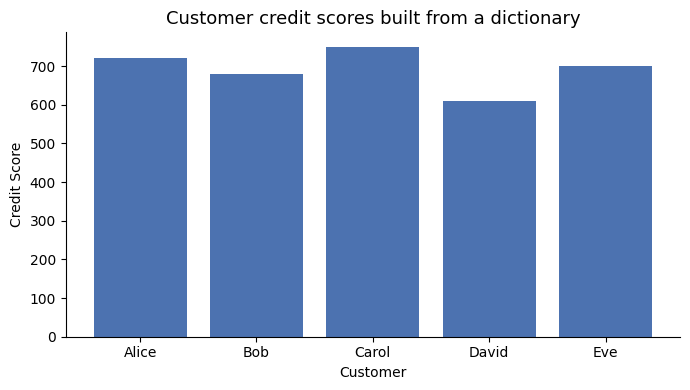

In [5]:
customer_features = {
    "name":    ["Alice", "Bob", "Carol", "David", "Eve"],
    "age":     [28, 34, 23, 45, 31],
    "score":   [720, 680, 750, 610, 700],
    "premium": [True, False, True, False, True],
}

df = pd.DataFrame(customer_features)
print(df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(customer_features["name"], customer_features["score"], color="#4C72B0")
ax.set_title("Customer credit scores built from a dictionary", fontsize=13)
ax.set_xlabel("Customer")
ax.set_ylabel("Credit Score")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Data structure cheat sheet for data science

| Situation | Use this | Why |
|-----------|----------|-----|
| Ordered sequence of rows or values | `list` | Append-friendly, iterable, sliceable |
| Fixed record you will not modify | `tuple` | Immutable, hashable, safe as dict key |
| Column-name to data mapping | `dict` | O(1) lookup by name, converts directly to DataFrame |
| Checking whether a value has been seen | `set` | O(1) membership test regardless of size |
| Tabular data with named columns | `pd.DataFrame` | Built on dict + numpy, optimized for analytics |
| Multi-dimensional numeric array | `np.ndarray` | C-speed math over large arrays |

---
## Key takeaway

> **Lists, tuples, dicts, and sets each trade off order, mutability, and lookup speed; choosing the right one is often the difference between readable, fast code and a pipeline that is slow and hard to debug.**

---
*Next up: String Methods — how to clean and transform the text data that fills the `object` columns of every real-world DataFrame*